In [2]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

In [3]:
# define parent folder file
folderpath = "/data/visitor/ihhg69/id13/20260409/PROCESSED_DATA/"
folder = Path(folderpath)
for f in folder.iterdir():
    print(f.name)

dq_pap163
dq_pap217
workflows
pap163
pap217
__van
dq_modernpap
BLA
__CALIB
dq_al2o3
siemens
modernpap
al2o3


In [4]:
sample_folder_name = "dq_modernpap"
sample_folder = os.path.join(folderpath,sample_folder_name)
for f in Path(sample_folder).iterdir():
    print(f.name)

dq_modernpap_roi146589_164517
dq_modernpap_roi146587_164515
dq_modernpap_roi146585_164514
dq_modernpap_roi146588_164516


In [5]:
dataset_folder_name = "dq_modernpap_roi146587_164515"
dataset_folder = os.path.join(sample_folder, dataset_folder_name)
for f in Path(dataset_folder).iterdir():
    print(f.name)

workflows
gallery
dq_modernpap_roi146587_164515.h5


In [6]:
scan_path_name = dataset_folder_name
scan_path = os.path.join(dataset_folder, scan_path_name + ".h5")
with h5py.File(scan_path, 'r') as f:
    def print_tree(name, obj):
        print(name)

    f.visititems(print_tree)

1.1
1.1/eiger_average
1.1/eiger_average/average
1.1/eiger_average/average/2th
1.1/eiger_average/average/average_intensity
1.1/eiger_average/average/reference_alpha_Al2O3
1.1/eiger_average/name
1.1/eiger_diffmap
1.1/eiger_diffmap/configuration
1.1/eiger_diffmap/configuration/data
1.1/eiger_diffmap/configuration/type
1.1/eiger_diffmap/diffmap
1.1/eiger_diffmap/diffmap/2th
1.1/eiger_diffmap/diffmap/ct34
1.1/eiger_diffmap/diffmap/dark_value
1.1/eiger_diffmap/diffmap/intensity
1.1/eiger_diffmap/diffmap/intensity_norm
1.1/eiger_diffmap/diffmap/map
1.1/eiger_diffmap/diffmap/map_norm
1.1/eiger_diffmap/diffmap/xpoints
1.1/eiger_diffmap/diffmap/ypoints
1.1/eiger_diffmap/dim0
1.1/eiger_diffmap/dim1
1.1/eiger_diffmap/dim2
1.1/eiger_diffmap/mask_file
1.1/eiger_diffmap/name
1.1/eiger_diffmap/offset
1.1/eiger_integrate
1.1/eiger_integrate/configuration
1.1/eiger_integrate/configuration/data
1.1/eiger_integrate/configuration/type
1.1/eiger_integrate/integrated
1.1/eiger_integrate/integrated/2th
1.1/ei

In [7]:
twotheta_path = f"/1.1/eiger_integrate/integrated/2th"
intensity_path = f"/1.1/eiger_integrate/integrated/intensity"

with h5py.File(scan_path, 'r') as f:
    x = f[twotheta_path][:]
    patterns = f[intensity_path][:]

In [8]:
print("x shape:", x.shape)
print("patterns shape:", patterns.shape)
print("patterns dtype:", patterns.dtype)

x shape: (1050,)
patterns shape: (51200, 1050)
patterns dtype: float32


In [9]:
n_rows = 320
n_cols = 160

if patterns.ndim == 2:
    n_pixels, n_points = patterns.shape
    
    if n_pixels != n_rows * n_cols:
        raise ValueError(f"Expected {n_rows*n_cols} pixels, but got {n_pixels}")
    
    patterns_map = patterns.reshape(n_rows, n_cols, n_points)

elif patterns.ndim == 3:
    if patterns.shape[0] != n_rows or patterns.shape[1] != n_cols:
        raise ValueError(f"Expected shape ({n_rows}, {n_cols}, n_points), but got {patterns.shape}")
    
    patterns_map = patterns
    n_points = patterns.shape[-1]

else:
    raise ValueError("patterns should be either 2D or 3D")

print("patterns_map shape:", patterns_map.shape)

patterns_map shape: (320, 160, 1050)


In [10]:
from ipywidgets import interact, IntSlider
from matplotlib.widgets import RectangleSelector
%matplotlib widget
# Compute total intensity map once
total_intensity_map = patterns_map.sum(axis=2)

print("patterns_map shape:", patterns_map.shape)
print("total_intensity_map shape:", total_intensity_map.shape)

patterns_map shape: (320, 160, 1050)
total_intensity_map shape: (320, 160)


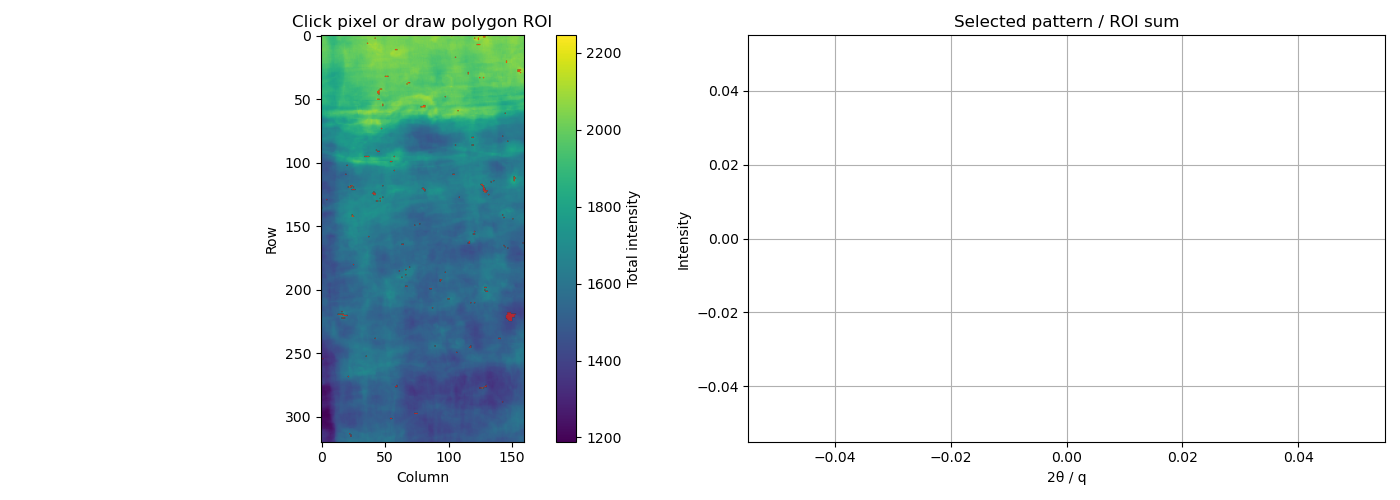

In [11]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import PolygonSelector
from matplotlib.path import Path
import ipywidgets as widgets
from IPython.display import display
from pathlib import Path as FilePath
from matplotlib.colors import ListedColormap

# ==================================================
# USER SETTINGS
# ==================================================
save_folder = FilePath("saved_roi_patterns")
save_folder.mkdir(exist_ok=True)

# ==================================================
# Maps
# ==================================================
total_intensity_map = patterns_map.sum(axis=2)

# For each pixel, find the maximum intensity along the 1D diffractogram
# Pixels with max intensity above threshold will be marked red and excluded
max_intensity_map = patterns_map.max(axis=2)

n_rows, n_cols, n_channels = patterns_map.shape

# ==================================================
# Initial threshold
# ==================================================
initial_threshold = np.percentile(max_intensity_map, 99.5)

threshold_min = float(np.percentile(max_intensity_map, 90))
threshold_max = float(np.percentile(max_intensity_map, 100))

threshold_step = (threshold_max - threshold_min) / 500
if threshold_step == 0:
    threshold_step = 1.0

# ==================================================
# Widgets
# ==================================================
mode = widgets.ToggleButtons(
    options=["Click pixel", "Draw polygon ROI"],
    value="Click pixel",
    description="Mode:"
)

threshold_slider = widgets.FloatSlider(
    value=float(initial_threshold),
    min=threshold_min,
    max=threshold_max,
    step=threshold_step,
    description="Threshold:",
    continuous_update=False,
    readout_format=".2e",
    layout=widgets.Layout(width="600px")
)

set_threshold_button = widgets.Button(
    description="Set threshold by prompt",
    button_style="primary"
)

save_name = widgets.Text(
    value="roi_pattern",
    description="Save name:"
)

save_xy_button = widgets.Button(
    description="Save .xy",
    button_style="success"
)

save_npz_button = widgets.Button(
    description="Save .npz",
    button_style="info"
)

clear_button = widgets.Button(
    description="Clear selection",
    button_style="warning"
)

info = widgets.HTML(value="<b>Mode:</b> Click pixel")

display(
    widgets.VBox([
        mode,
        widgets.HBox([threshold_slider, set_threshold_button]),
        widgets.HBox([save_name, save_xy_button, save_npz_button, clear_button]),
        info
    ])
)

# ==================================================
# Store selected data
# ==================================================
selected = {
    "type": None,
    "row": None,
    "col": None,
    "polygon_vertices": None,
    "polygon_mask": None,
    "bad_pixel_mask": None,
    "final_roi_mask": None,
    "roi_rows": None,
    "roi_cols": None,
    "excluded_rows": None,
    "excluded_cols": None,
    "pattern": None,
    "threshold": None
}

# ==================================================
# Figure
# ==================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 2D total intensity map
im = axes[0].imshow(
    total_intensity_map,
    origin="upper",
    aspect="equal",
    cmap="viridis"
)

marker = axes[0].scatter([], [], s=80, marker="x", linewidths=2)

axes[0].set_title("Click pixel or draw polygon ROI")
axes[0].set_xlabel("Column")
axes[0].set_ylabel("Row")
fig.colorbar(im, ax=axes[0], label="Total intensity")

# --------------------------------------------------
# Red overlay for excluded pixels
# --------------------------------------------------
bad_pixel_mask_initial = max_intensity_map > threshold_slider.value
red_cmap = ListedColormap(["red"])

bad_overlay = axes[0].imshow(
    np.ma.masked_where(~bad_pixel_mask_initial, bad_pixel_mask_initial),
    origin="upper",
    aspect="equal",
    cmap=red_cmap,
    alpha=0.65
)

# 1D pattern
line, = axes[1].plot([], [])
axes[1].set_xlabel("2θ / q")
axes[1].set_ylabel("Intensity")
axes[1].set_title("Selected pattern / ROI sum")
axes[1].grid()

plt.tight_layout()

# ==================================================
# Helper function to update 1D plot
# ==================================================
def update_pattern_plot(y, title):
    line.set_data(x, y)
    axes[1].relim()
    axes[1].autoscale_view()
    axes[1].set_title(title)
    fig.canvas.draw_idle()

# ==================================================
# Helper function to update red bad-pixel overlay
# ==================================================
def get_bad_pixel_mask():
    threshold = threshold_slider.value
    return max_intensity_map > threshold

def update_bad_pixel_overlay():
    threshold = threshold_slider.value
    bad_pixel_mask = get_bad_pixel_mask()

    bad_overlay.set_data(
        np.ma.masked_where(~bad_pixel_mask, bad_pixel_mask)
    )

    n_bad = np.count_nonzero(bad_pixel_mask)

    info.value = (
        f"<b>Threshold updated:</b> max(I) > {threshold:.3e} | "
        f"{n_bad} pixels marked in red and excluded from ROI sum"
    )

    fig.canvas.draw_idle()

# ==================================================
# Threshold slider behavior
# ==================================================
def on_threshold_change(change):
    update_bad_pixel_overlay()

threshold_slider.observe(on_threshold_change, names="value")

# ==================================================
# Threshold prompt button
# ==================================================
def set_threshold_by_prompt(button):
    current = threshold_slider.value

    value = input(
        f"Enter new threshold value for max intensity filtering "
        f"(current = {current:.3e}): "
    )

    try:
        value = float(value)
    except ValueError:
        info.value = "<b>Error:</b> threshold must be a number."
        return

    # Expand slider range if the prompted value is outside current range
    if value < threshold_slider.min:
        threshold_slider.min = value

    if value > threshold_slider.max:
        threshold_slider.max = value

    threshold_slider.value = value

    update_bad_pixel_overlay()

set_threshold_button.on_click(set_threshold_by_prompt)

# ==================================================
# Click pixel function
# ==================================================
def onclick(event):
    if mode.value != "Click pixel":
        return

    if event.inaxes != axes[0]:
        return

    if event.xdata is None or event.ydata is None:
        return

    col = int(round(event.xdata))
    row = int(round(event.ydata))

    if row < 0 or row >= n_rows:
        return
    if col < 0 or col >= n_cols:
        return

    y = patterns_map[row, col, :]

    marker.set_offsets([[col, row]])

    update_pattern_plot(
        y,
        f"Pattern at row={row}, col={col}"
    )

    axes[0].set_title(f"Selected pixel: row={row}, col={col}")

    threshold = threshold_slider.value
    bad_pixel_mask = get_bad_pixel_mask()

    selected["type"] = "pixel"
    selected["row"] = row
    selected["col"] = col
    selected["polygon_vertices"] = None
    selected["polygon_mask"] = None
    selected["bad_pixel_mask"] = bad_pixel_mask
    selected["final_roi_mask"] = None
    selected["roi_rows"] = None
    selected["roi_cols"] = None
    selected["excluded_rows"] = None
    selected["excluded_cols"] = None
    selected["pattern"] = y
    selected["threshold"] = threshold

    if bad_pixel_mask[row, col]:
        info.value = (
            f"<b>Pixel selected:</b> row={row}, col={col} | "
            f"<span style='color:red'>above threshold</span>"
        )
    else:
        info.value = f"<b>Pixel selected:</b> row={row}, col={col}"

    fig.canvas.draw_idle()

# ==================================================
# Polygon ROI function
# ==================================================
def on_polygon_select(vertices):
    if mode.value != "Draw polygon ROI":
        return

    if vertices is None or len(vertices) < 3:
        info.value = "<b>Warning:</b> Polygon needs at least 3 points."
        return

    vertices = np.array(vertices)

    polygon_path = Path(vertices)

    # Grid of pixel centers
    col_grid, row_grid = np.meshgrid(
        np.arange(n_cols),
        np.arange(n_rows)
    )

    points = np.vstack(
        (col_grid.ravel(), row_grid.ravel())
    ).T

    # Pixels inside polygon
    polygon_mask = polygon_path.contains_points(points)
    polygon_mask = polygon_mask.reshape((n_rows, n_cols))

    # Bad pixels from current threshold
    threshold = threshold_slider.value
    bad_pixel_mask = get_bad_pixel_mask()

    # Final ROI excludes red pixels
    final_roi_mask = polygon_mask & (~bad_pixel_mask)

    # Pixels excluded inside polygon
    excluded_mask = polygon_mask & bad_pixel_mask

    roi_rows, roi_cols = np.where(final_roi_mask)
    excluded_rows, excluded_cols = np.where(excluded_mask)

    if len(roi_rows) == 0:
        info.value = (
            "<b>Warning:</b> No valid pixels left inside polygon ROI "
            "after threshold filtering."
        )
        return

    roi_patterns = patterns_map[final_roi_mask, :]

    # SUM, not mean
    sum_pattern = roi_patterns.sum(axis=0)

    # Hide click marker
    marker.set_offsets(np.empty((0, 2)))

    update_pattern_plot(
        sum_pattern,
        f"Summed polygon ROI pattern | {len(roi_rows)} valid pixels"
    )

    axes[0].set_title(
        f"Polygon ROI | valid={len(roi_rows)}, excluded={len(excluded_rows)}"
    )

    selected["type"] = "polygon_roi_sum_thresholded"
    selected["row"] = None
    selected["col"] = None
    selected["polygon_vertices"] = vertices
    selected["polygon_mask"] = polygon_mask
    selected["bad_pixel_mask"] = bad_pixel_mask
    selected["final_roi_mask"] = final_roi_mask
    selected["roi_rows"] = roi_rows
    selected["roi_cols"] = roi_cols
    selected["excluded_rows"] = excluded_rows
    selected["excluded_cols"] = excluded_cols
    selected["pattern"] = sum_pattern
    selected["threshold"] = threshold

    info.value = (
        f"<b>Polygon ROI selected:</b> "
        f"{len(roi_rows)} valid pixels summed | "
        f"{len(excluded_rows)} high-intensity pixels excluded | "
        f"threshold = {threshold:.3e}"
    )

    fig.canvas.draw_idle()

# ==================================================
# Polygon selector
# ==================================================
selector = PolygonSelector(
    axes[0],
    on_polygon_select,
    useblit=True,
    props=dict(linewidth=2, alpha=0.8),
    handle_props=dict(marker="o", markersize=5, alpha=0.8)
)

selector.set_active(False)

# ==================================================
# Mode change behavior
# ==================================================
def on_mode_change(change):
    if change["new"] == "Click pixel":
        selector.set_active(False)
        info.value = "<b>Mode:</b> Click pixel"

    elif change["new"] == "Draw polygon ROI":
        selector.set_active(True)
        info.value = (
            "<b>Mode:</b> Draw polygon ROI | "
            "Click several points, then double-click to close the polygon. "
            "Red pixels will be excluded from the ROI sum."
        )

mode.observe(on_mode_change, names="value")

# ==================================================
# Save .xy
# ==================================================
def save_xy_clicked(button):
    if selected["pattern"] is None:
        info.value = "<b>Nothing to save:</b> select a pixel or ROI first."
        return

    filename = save_folder / f"{save_name.value}.xy"

    data_to_save = np.column_stack([
        x,
        selected["pattern"]
    ])

    np.savetxt(
        filename,
        data_to_save,
        fmt="%.8f %.8f"
    )

    info.value = f"<b>Saved .xy:</b> {filename}"

save_xy_button.on_click(save_xy_clicked)

# ==================================================
# Save .npz
# ==================================================
def save_npz_clicked(button):
    if selected["pattern"] is None:
        info.value = "<b>Nothing to save:</b> select a pixel or ROI first."
        return

    filename = save_folder / f"{save_name.value}.npz"

    np.savez(
        filename,
        type=selected["type"],
        x=x,
        pattern=selected["pattern"],

        row=-1 if selected["row"] is None else selected["row"],
        col=-1 if selected["col"] is None else selected["col"],

        polygon_vertices=selected["polygon_vertices"],
        polygon_mask=selected["polygon_mask"],

        bad_pixel_mask=selected["bad_pixel_mask"],
        final_roi_mask=selected["final_roi_mask"],

        roi_rows=selected["roi_rows"],
        roi_cols=selected["roi_cols"],

        excluded_rows=selected["excluded_rows"],
        excluded_cols=selected["excluded_cols"],

        threshold=selected["threshold"]
    )

    info.value = f"<b>Saved .npz:</b> {filename}"

save_npz_button.on_click(save_npz_clicked)

# ==================================================
# Clear selection
# ==================================================
def clear_selection(button):
    marker.set_offsets(np.empty((0, 2)))

    try:
        selector.clear()
    except:
        pass

    line.set_data([], [])
    axes[1].relim()
    axes[1].autoscale_view()

    axes[0].set_title("Click pixel or draw polygon ROI")
    axes[1].set_title("Selected pattern / ROI sum")

    selected["type"] = None
    selected["row"] = None
    selected["col"] = None
    selected["polygon_vertices"] = None
    selected["polygon_mask"] = None
    selected["bad_pixel_mask"] = None
    selected["final_roi_mask"] = None
    selected["roi_rows"] = None
    selected["roi_cols"] = None
    selected["excluded_rows"] = None
    selected["excluded_cols"] = None
    selected["pattern"] = None
    selected["threshold"] = None

    info.value = "<b>Selection cleared.</b>"

    fig.canvas.draw_idle()

clear_button.on_click(clear_selection)

# ==================================================
# Connect click event
# ==================================================
cid = fig.canvas.mpl_connect("button_press_event", onclick)

plt.show()